# 🚢 한강변 신규 선착장 입지 분석 — ML 기반 스코어링

**분석 개요**  
한강변을 따라 200m 간격으로 후보 지점을 자동 생성한 뒤,  
각 지점의 지하철 접근성·관광 근접성·인구·차별성을 피처로 삼아  
XGBoost 기반으로 최적 선착장 입지를 도출합니다.

```
한강변 200m 간격 후보지 생성
  → 기존 선착장 1km 이내 제외
  → 5개 피처 계산
  → Min-Max 정규화
  → 베이스라인 가중합
  → XGBoost 피처 중요도 추출 → 재스코어링
  → TOP 10 + Folium 지도
```

---
> **설정**: 아래 `DATA_PATH`를 본인 환경에 맞게 수정하세요.

In [1]:
# !pip install pandas numpy scikit-learn xgboost scipy folium matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──────────────────────────────────────────
DATA_PATH = '최종_한강_모든_장소_통합_정보.xlsx'  # ← 수정
# ──────────────────────────────────────────────────────
print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
xl     = pd.read_excel(DATA_PATH, sheet_name=None)
subway = xl['지하철역'].copy()
docks  = xl['한강버스선착장'].copy()
tour   = xl['관광명소'].copy()
night  = xl['야경명소'].copy()
admin  = xl['한강1km행정동'].copy()

print(f'지하철역: {len(subway)}개 | 기존선착장: {len(docks)}개 | 관광명소: {len(tour)}개 | 야경명소: {len(night)}개')
docks[['선착장명','위도','경도']]

지하철역: 72개 | 기존선착장: 7개 | 관광명소: 42개 | 야경명소: 15개


,선착장명,위도,경도
0,마곡,37.575677,126.839846
1,망원,37.553748,126.895687
2,여의도,37.528392,126.935152
3,옥수,37.539265,127.017772
4,압구정,37.534978,127.026365
5,뚝섬,37.528571,127.067339
6,잠실,37.518625,127.075482


## 2. 한강변 후보 지점 자동 생성

한강 중심선을 따라 **200m 간격**으로 후보 좌표를 보간합니다.  
`INTERVAL_M`을 바꾸면 간격 조정, `HANGANG_SPINE`에 좌표를 추가하면 구간 확장이 가능합니다.

In [3]:
# ── 파라미터 ─────────────────────────────────────────
INTERVAL_M        = 200    # 후보 지점 간격 (m)
DOCK_EXCLUSION_M  = 1000   # 기존 선착장 인근 제외 반경 (m)
SUBWAY_RADIUS_M   = 1500   # 지하철역 접근성 계산 반경 (m)
POI_RADIUS_M      = 2000   # 관광지 근접성 계산 반경 (m)
DOCK_DIST_CAP_M   = 5000   # 차별성 거리 상한 (m)
# ──────────────────────────────────────────────────────

# 한강 중심선 척추 좌표 (마곡 ~ 잠실, 서쪽→동쪽)
HANGANG_SPINE = [
    (37.5757, 126.8398),  # 마곡
    (37.5680, 126.8550),
    (37.5620, 126.8700),
    (37.5570, 126.8830),  # 망원
    (37.5510, 126.8950),
    (37.5480, 126.9100),
    (37.5410, 126.9220),
    (37.5380, 126.9300),  # 여의도
    (37.5290, 126.9350),
    (37.5250, 126.9440),
    (37.5230, 126.9530),
    (37.5210, 126.9640),  # 반포
    (37.5180, 126.9750),
    (37.5160, 126.9870),
    (37.5150, 127.0000),
    (37.5180, 127.0120),  # 옥수·압구정
    (37.5250, 127.0200),
    (37.5300, 127.0280),
    (37.5260, 127.0400),
    (37.5230, 127.0520),  # 뚝섬
    (37.5210, 127.0620),
    (37.5200, 127.0720),
    (37.5190, 127.0850),  # 잠실
    (37.5185, 127.1000),
]

def haversine(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리 (m)"""
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin(np.radians(lat2-lat1)/2)**2
         + np.cos(phi1)*np.cos(phi2)*np.sin(np.radians(lon2-lon1)/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def generate_candidates(spine, interval_m):
    """한강 척추 좌표를 interval_m 간격으로 보간해 후보 지점 생성"""
    pts = []
    for i in range(len(spine)-1):
        lat1, lon1 = spine[i]
        lat2, lon2 = spine[i+1]
        seg_d = haversine(lat1, lon1, lat2, lon2)
        n = max(1, int(seg_d / interval_m))
        for j in range(n):
            t = j / n
            pts.append({'위도': lat1 + t*(lat2-lat1),
                        '경도': lon1 + t*(lon2-lon1)})
    pts.append({'위도': spine[-1][0], '경도': spine[-1][1]})
    return pd.DataFrame(pts).reset_index(names='후보ID')

candidates = generate_candidates(HANGANG_SPINE, INTERVAL_M)
print(f'생성된 후보 지점: {len(candidates)}개 (약 {len(candidates)*INTERVAL_M/1000:.1f}km 구간)')
candidates.head()

생성된 후보 지점: 117개 (약 23.4km 구간)


,후보ID,위도,경도
0,0,37.5757,126.839800
1,1,37.5746,126.841971
2,2,37.5735,126.844143
3,3,37.5724,126.846314
4,4,37.5713,126.848486


## 3. 기존 선착장 1km 이내 후보 제외

In [4]:
def min_dist_to_ref(lat, lon, ref_df):
    return ref_df.apply(lambda r: haversine(lat, lon, r['위도'], r['경도']), axis=1).min()

candidates['기존선착장_최소거리(m)'] = candidates.apply(
    lambda r: min_dist_to_ref(r['위도'], r['경도'], docks), axis=1)

before = len(candidates)
candidates = candidates[candidates['기존선착장_최소거리(m)'] >= DOCK_EXCLUSION_M].reset_index(drop=True)
print(f'기존 선착장 {DOCK_EXCLUSION_M}m 이내 제외: {before}개 → {len(candidates)}개')

기존 선착장 1000m 이내 제외: 117개 → 78개


## 4. 피처 엔지니어링

| 피처 | 설명 |
|------|------|
| F1 지하철 접근성 | 반경 1.5km 내 지하철역 이용량 × 거리 가중합 |
| F2 관광·야경 근접성 | 반경 2km 내 POI SNS언급량 × 거리 가중합 |
| F3 인구·종사자 | 가장 가까운 지하철역의 행정동 인구+종사자 |
| F4 기존 선착장 차별성 | 기존 선착장까지 최소거리 (멀수록 가산점) |
| F5 한강변 인접성 | 척추선에서 벗어난 정도 (보정용, 보간이므로 균일) |

In [5]:
all_pois = pd.concat([tour, night], ignore_index=True)

def weighted_subway_score(lat, lon, subway_df, radius=SUBWAY_RADIUS_M):
    """반경 내 지하철역 이용량 × (1 - d/r) 가중합"""
    total = 0
    for _, r in subway_df.iterrows():
        d = haversine(lat, lon, r['위도'], r['경도'])
        if d <= radius:
            total += r['하루평균_총이용량'] * (1 - d / radius)
    return total

def weighted_poi_score(lat, lon, poi_df, radius=POI_RADIUS_M, default_sns=500):
    """반경 내 POI SNS언급량 × (1 - d/r) 가중합"""
    total = 0
    for _, r in poi_df.iterrows():
        d = haversine(lat, lon, r['위도'], r['경도'])
        if d <= radius:
            sns_val = r.get('월평균_SNS언급횟수', np.nan)
            sns_val = sns_val if pd.notna(sns_val) else default_sns
            total += sns_val * (1 - d / radius)
    return total

def nearest_admin_pop(lat, lon, subway_df):
    """가장 가까운 지하철역 행정동의 인구+종사자"""
    dists = subway_df.apply(lambda r: haversine(lat, lon, r['위도'], r['경도']), axis=1)
    nearest = subway_df.iloc[dists.idxmin()]
    return nearest['행정동_인구수'] + nearest['행정동_총종사자수']

print('⏳ 피처 계산 중... (1~2분 소요)')

candidates['f_subway']     = candidates.apply(
    lambda r: weighted_subway_score(r['위도'], r['경도'], subway), axis=1)
candidates['f_tourism']    = candidates.apply(
    lambda r: weighted_poi_score(r['위도'], r['경도'], all_pois), axis=1)
candidates['f_population'] = candidates.apply(
    lambda r: nearest_admin_pop(r['위도'], r['경도'], subway), axis=1)
candidates['f_distance']   = candidates['기존선착장_최소거리(m)'].clip(0, DOCK_DIST_CAP_M)

print(f'✅ 피처 계산 완료 — {len(candidates)}개 후보지')
candidates[['후보ID','위도','경도','f_subway','f_tourism','f_population','f_distance']].head()

⏳ 피처 계산 중... (1~2분 소요)
✅ 피처 계산 완료 — 78개 후보지


,후보ID,위도,경도,f_subway,f_tourism,f_population,f_distance
0,5,37.570200,126.850657,23015.699387,1742.328203,113284,1130.801853
1,6,37.569100,126.852829,25309.451464,1154.865293,50629,1357.927985
2,7,37.568000,126.855000,28095.058234,560.335167,50629,1585.056499
3,8,37.567143,126.857143,28462.734551,216.572792,50629,1795.647742
4,9,37.566286,126.859286,28223.237699,28.657117,50629,2006.442455


## 5. 정규화 & 베이스라인 스코어링

In [6]:
# ── 가중치 (합계 1.0) — 자유롭게 조정 ─────────────────
WEIGHTS = {
    'subway':     0.35,   # 지하철 접근성
    'tourism':    0.30,   # 관광·야경 근접성
    'population': 0.20,   # 인구·종사자
    'distance':   0.15,   # 기존 선착장 차별성
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9
# ──────────────────────────────────────────────────────

def minmax(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(np.zeros(len(s)), index=s.index)

candidates['n_subway']     = minmax(candidates['f_subway'])
candidates['n_tourism']    = minmax(candidates['f_tourism'])
candidates['n_population'] = minmax(candidates['f_population'])
candidates['n_distance']   = minmax(candidates['f_distance'])

FEAT_COLS = ['n_subway','n_tourism','n_population','n_distance']
W_LIST    = [WEIGHTS['subway'], WEIGHTS['tourism'], WEIGHTS['population'], WEIGHTS['distance']]

candidates['baseline_score'] = sum(
    W_LIST[i] * candidates[FEAT_COLS[i]] for i in range(4)
) * 100

top10_base = candidates.nlargest(10, 'baseline_score').reset_index(drop=True)
top10_base.index += 1
top10_base[['위도','경도','f_subway','f_tourism','f_population','기존선착장_최소거리(m)','baseline_score']]\
    .style.background_gradient(subset=['baseline_score'], cmap='YlGn')\
    .format({'baseline_score':'{:.1f}','기존선착장_최소거리(m)':'{:.0f}',
             'f_subway':'{:,.0f}','f_tourism':'{:,.0f}','f_population':'{:,.0f}'})

,위도,경도,f_subway,f_tourism,f_population,기존선착장_최소거리(m),baseline_score
1,37.518500,127.100000,"153,091","11,191","33,304",2162,60.0
2,37.518583,127.097500,"129,373","11,351","33,304",1942,53.6
3,37.524500,126.946250,"15,442","15,231","226,113",1070,47.4
4,37.518667,127.095000,"102,431","10,989","33,304",1721,45.7
5,37.546833,126.912000,"96,074","8,710","29,487",1631,39.7
6,37.545667,126.914000,"87,740","9,006","29,487",1848,39.3
7,37.519800,126.968400,"57,921","6,123","76,568",3084,38.2
8,37.520400,126.966200,"63,798","5,819","76,568",2879,38.1
9,37.518750,127.092500,"75,276","10,257","38,602",1501,37.6
10,37.519200,126.970600,"48,452","6,315","76,568",3289,37.3


## 6. XGBoost & RandomForest — 피처 중요도 비교

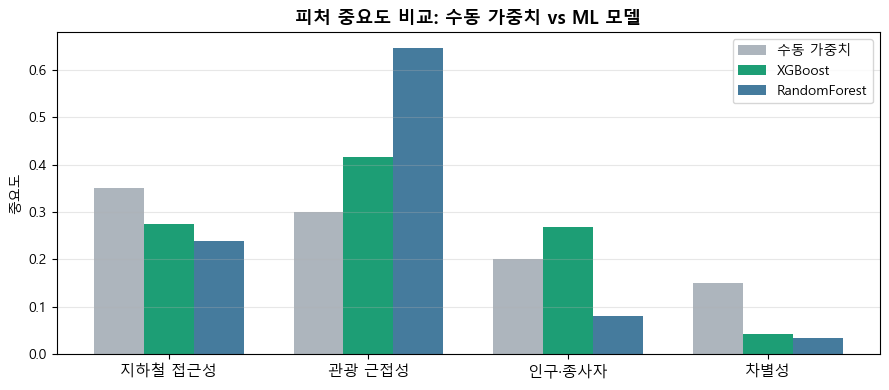

,수동가중치,XGBoost,RandomForest
피처,,,
지하철 접근성,0.35,0.274,0.240
관광 근접성,0.30,0.416,0.646
인구·종사자,0.20,0.268,0.080
차별성,0.15,0.043,0.034


In [7]:
X = candidates[FEAT_COLS].values
y = candidates['baseline_score'].values

# ── XGBoost ─────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X, y)

# ── RandomForest (비교용) ────────────────────────────
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

FEAT_NAMES = ['지하철 접근성','관광 근접성','인구·종사자','차별성']
importance_df = pd.DataFrame({
    '피처': FEAT_NAMES,
    '수동가중치': W_LIST,
    'XGBoost': xgb.feature_importances_,
    'RandomForest': rf.feature_importances_,
})

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(FEAT_NAMES))
w = 0.25
ax.bar(x-w, importance_df['수동가중치'],   width=w, label='수동 가중치',  color='#adb5bd')
ax.bar(x,   importance_df['XGBoost'],     width=w, label='XGBoost',     color='#1D9E75')
ax.bar(x+w, importance_df['RandomForest'],width=w, label='RandomForest',color='#457b9d')
ax.set_xticks(x)
ax.set_xticklabels(FEAT_NAMES, fontsize=11)
ax.set_ylabel('중요도')
ax.set_title('피처 중요도 비교: 수동 가중치 vs ML 모델', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

importance_df.set_index('피처').round(3)

## 7. XGBoost 중요도로 재스코어링 & 순위 비교

In [8]:
xgb_w = xgb.feature_importances_ / xgb.feature_importances_.sum()

candidates['xgb_score'] = sum(
    xgb_w[i] * candidates[FEAT_COLS[i]] for i in range(len(FEAT_COLS))
) * 100

candidates['rank_base'] = candidates['baseline_score'].rank(ascending=False).astype(int)
candidates['rank_xgb']  = candidates['xgb_score'].rank(ascending=False).astype(int)
candidates['rank_diff'] = candidates['rank_base'] - candidates['rank_xgb']

top10_xgb = candidates.nlargest(10, 'xgb_score').reset_index(drop=True)
top10_xgb.index += 1

display_df = top10_xgb[['위도','경도','baseline_score','rank_base','xgb_score','rank_xgb','rank_diff',
                          'n_subway','n_tourism','n_population','n_distance','기존선착장_최소거리(m)']].copy()
display_df.rename(columns={
    'baseline_score':'베이스라인','rank_base':'기존순위',
    'xgb_score':'XGB점수','rank_xgb':'XGB순위','rank_diff':'순위변화',
    'n_subway':'지하철','n_tourism':'관광','n_population':'인구','n_distance':'차별성',
    '기존선착장_최소거리(m)':'선착장거리(m)'
}, inplace=True)

def highlight_change(val):
    if val > 0: return 'color:green;font-weight:bold'
    if val < 0: return 'color:red;font-weight:bold'
    return ''

display_df.style\
    .applymap(highlight_change, subset=['순위변화'])\
    .background_gradient(subset=['XGB점수'], cmap='YlGn')\
    .format({'베이스라인':'{:.1f}','XGB점수':'{:.1f}','순위변화':'{:+d}',
             '지하철':'{:.2f}','관광':'{:.2f}','인구':'{:.2f}','차별성':'{:.2f}',
             '선착장거리(m)':'{:.0f}','위도':'{:.5f}','경도':'{:.5f}'})

,위도,경도,베이스라인,기존순위,XGB점수,XGB순위,순위변화,지하철,관광,인구,차별성,선착장거리(m)
1,37.52450,126.94625,47.4,3,63.0,1,+2,0.08,0.82,1.00,0.01,1070
2,37.51850,127.10000,60.0,1,56.0,2,-1,1.00,0.60,0.08,0.36,2162
3,37.51858,127.09750,53.6,2,51.7,3,-1,0.84,0.61,0.08,0.29,1942
4,37.53800,126.93000,35.2,15,46.3,4,+11,0.08,1.00,0.08,0.04,1161
5,37.51867,127.09500,45.7,4,45.6,5,-1,0.66,0.59,0.08,0.22,1721
6,37.53900,126.92733,33.8,20,43.3,6,+14,0.08,0.92,0.08,0.10,1366
7,37.51875,127.09250,37.6,9,39.4,7,+2,0.48,0.55,0.10,0.15,1501
8,37.54000,126.92467,32.4,23,39.3,8,+15,0.12,0.80,0.08,0.18,1588
9,37.54683,126.91200,39.7,5,38.8,9,-4,0.62,0.47,0.06,0.19,1631
10,37.54567,126.91400,39.3,6,38.2,10,-4,0.56,0.48,0.06,0.26,1848


## 8. 종합 시각화

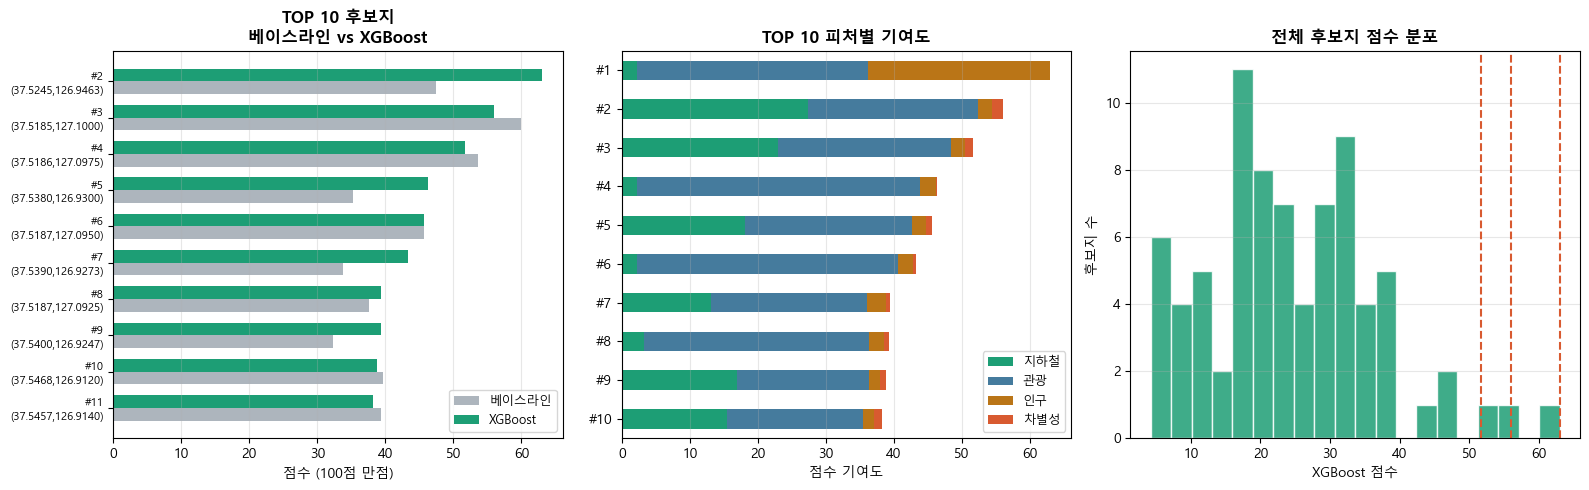

📊 저장: 한강변_입지분석_결과.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ① TOP10 점수 비교 (수평 막대)
ax = axes[0]
labels = [f"#{i+1}\n({row['위도']:.4f},{row['경도']:.4f})" for i, row in top10_xgb.iterrows()]
x = np.arange(len(top10_xgb))
w = 0.35
ax.barh(x+w/2, top10_xgb['baseline_score'], height=w, label='베이스라인', color='#adb5bd')
ax.barh(x-w/2, top10_xgb['xgb_score'],      height=w, label='XGBoost',   color='#1D9E75')
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('점수 (100점 만점)')
ax.set_title('TOP 10 후보지\n베이스라인 vs XGBoost', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ② 피처별 기여도 스택 바
ax = axes[1]
feat_cols_n = ['n_subway','n_tourism','n_population','n_distance']
feat_names  = ['지하철','관광','인구','차별성']
colors_b    = ['#1D9E75','#457b9d','#BA7517','#D85A30']
contrib = top10_xgb[feat_cols_n].multiply(xgb_w, axis=1) * 100
contrib.index = [f'#{i+1}' for i in range(len(top10_xgb))]
contrib.columns = feat_names
contrib.plot(kind='barh', stacked=True, ax=ax, color=colors_b, edgecolor='none')
ax.set_xlabel('점수 기여도')
ax.set_title('TOP 10 피처별 기여도', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# ③ 전체 후보지 점수 분포
ax = axes[2]
ax.hist(candidates['xgb_score'], bins=20, color='#1D9E75', edgecolor='white', alpha=0.85)
top3 = candidates.nlargest(3, 'xgb_score')
for _, row in top3.iterrows():
    ax.axvline(row['xgb_score'], color='#D85A30', linestyle='--', linewidth=1.5)
ax.set_xlabel('XGBoost 점수')
ax.set_ylabel('후보지 수')
ax.set_title('전체 후보지 점수 분포', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('한강변_입지분석_결과.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 저장: 한강변_입지분석_결과.png')

## 9. 레이더 차트 — TOP 5 비교

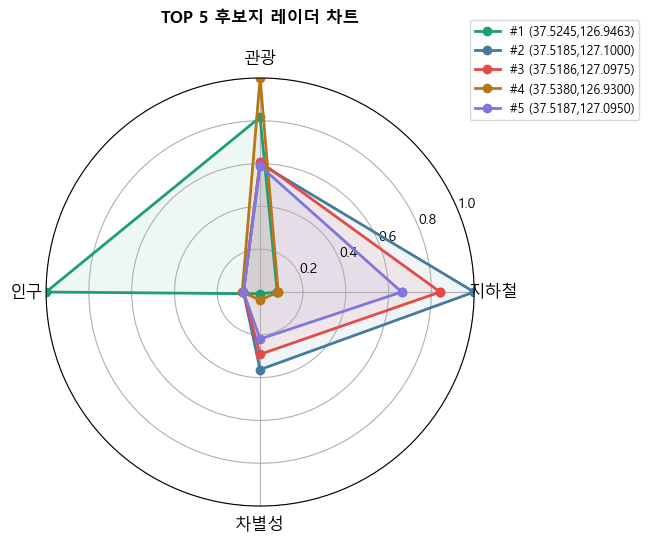

In [10]:
top5 = candidates.nlargest(5, 'xgb_score').reset_index(drop=True)
feat_cols_r = ['n_subway','n_tourism','n_population','n_distance']
feat_lab_r  = ['지하철','관광','인구','차별성']
n = len(feat_lab_r)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors_r = ['#1D9E75','#457b9d','#E24B4A','#BA7517','#7F77DD']

for i, row in top5.iterrows():
    vals = [row[c] for c in feat_cols_r] + [row[feat_cols_r[0]]]
    label = f"#{i+1} ({row['위도']:.4f},{row['경도']:.4f})"
    ax.plot(angles, vals, 'o-', lw=2, color=colors_r[i], label=label)
    ax.fill(angles, vals, alpha=0.08, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_lab_r, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('TOP 5 후보지 레이더 차트', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## 10. Folium 인터랙티브 지도

- 🟢 진한 초록: TOP 3 후보지 (원 크기 = 점수 비례)
- 🔵 파란 원: TOP 4~10 후보지
- 🔴 빨간 마커: 기존 선착장 7개
- 히트맵: 전체 후보지 점수 분포

지점을 클릭하면 세부 점수를 확인할 수 있습니다.

In [11]:
m = folium.Map(location=[37.530, 126.970], zoom_start=12, tiles='CartoDB positron')

# 전체 후보지 히트맵
heat_data = [[r['위도'], r['경도'], r['xgb_score']] for _, r in candidates.iterrows()]
HeatMap(heat_data, radius=18, blur=12, min_opacity=0.3,
        gradient={0.3:'blue', 0.6:'lime', 1.0:'red'}).add_to(m)

# 기존 선착장
for _, row in docks.iterrows():
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.Icon(color='red', icon='ship', prefix='fa'),
        tooltip=f"🚢 기존: {row['선착장명']} 선착장"
    ).add_to(m)

# TOP 10 후보지
for rank, row in top10_xgb.iterrows():
    rank_num = rank + 1
    color = '#0F6E56' if rank_num <= 3 else '#185FA5'
    radius = 18 - rank_num * 1.2
    popup_html = f"""
    <div style='font-family:sans-serif;width:230px'>
        <h4 style='margin:0;color:#0F6E56'>#{rank_num}위 후보 선착장</h4>
        <hr style='margin:4px 0'>
        <b>좌표:</b> {row['위도']:.5f}, {row['경도']:.5f}<br>
        <b>XGBoost 점수:</b> {row['xgb_score']:.1f}점<br>
        <b>베이스라인 점수:</b> {row['baseline_score']:.1f}점<br>
        <hr style='margin:4px 0'>
        지하철 접근성: {row['n_subway']:.2f}<br>
        관광 근접성:  {row['n_tourism']:.2f}<br>
        인구·종사자:  {row['n_population']:.2f}<br>
        차별성:      {row['n_distance']:.2f}<br>
        <b>기존 선착장까지:</b> {row['기존선착장_최소거리(m)']:.0f}m
    </div>"""
    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=radius, color=color, fill=True,
        fill_color=color, fill_opacity=0.85,
        tooltip=f"#{rank_num} XGB: {row['xgb_score']:.1f}점",
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(m)
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:10px;font-weight:bold;color:white;text-align:center;margin-top:3px">{rank_num}</div>',
            icon_size=(20,20), icon_anchor=(10,10)
        )
    ).add_to(m)

# 한강 척추선 표시
folium.PolyLine(
    [(lat, lon) for lat, lon in HANGANG_SPINE],
    color='#3B8BD4', weight=2, opacity=0.4,
    tooltip='한강 분석 구간'
).add_to(m)

map_path = '한강변_선착장_입지분석_지도.html'
m.save(map_path)
print(f'✅ 지도 저장: {map_path}')
m

✅ 지도 저장: 한강변_선착장_입지분석_지도.html


## 11. 결과 저장

In [12]:
out_cols = ['후보ID','위도','경도','f_subway','f_tourism','f_population','기존선착장_최소거리(m)',
            'n_subway','n_tourism','n_population','n_distance',
            'baseline_score','xgb_score','rank_base','rank_xgb','rank_diff']

result = candidates[out_cols].sort_values('xgb_score', ascending=False).reset_index(drop=True)
result.index += 1

with pd.ExcelWriter('한강변_선착장_입지분석_결과.xlsx', engine='openpyxl') as writer:
    result.to_excel(writer, sheet_name='전체후보지', index_label='XGB순위')
    result.head(10).to_excel(writer, sheet_name='TOP10', index_label='XGB순위')
    importance_df.to_excel(writer, sheet_name='피처중요도', index=False)

print('✅ 저장 완료: 한강변_선착장_입지분석_결과.xlsx')
print(f'\n🏆 최종 TOP 5 추천 후보 선착장 (한강변 지점):')
for i, row in result.head(5).iterrows():
    print(f'  {i}위. 위도 {row["위도"]:.5f} / 경도 {row["경도"]:.5f} — XGB점수: {row["xgb_score"]:.1f}점')

✅ 저장 완료: 한강변_선착장_입지분석_결과.xlsx

🏆 최종 TOP 5 추천 후보 선착장 (한강변 지점):
  1위. 위도 37.52450 / 경도 126.94625 — XGB점수: 63.0점
  2위. 위도 37.51850 / 경도 127.10000 — XGB점수: 56.0점
  3위. 위도 37.51858 / 경도 127.09750 — XGB점수: 51.7점
  4위. 위도 37.53800 / 경도 126.93000 — XGB점수: 46.3점
  5위. 위도 37.51867 / 경도 127.09500 — XGB점수: 45.6점


---
## 💡 실험 가이드

| 조정 항목 | 셀 | 변수명 |
|-----------|-----|--------|
| 후보지 간격 | 셀 5 | `INTERVAL_M` |
| 기존 선착장 제외 반경 | 셀 5 | `DOCK_EXCLUSION_M` |
| 지하철 접근성 계산 반경 | 셀 5 | `SUBWAY_RADIUS_M` |
| 관광지 근접성 계산 반경 | 셀 5 | `POI_RADIUS_M` |
| 수동 가중치 | 셀 8 | `WEIGHTS` |
| XGBoost 하이퍼파라미터 | 셀 9 | `n_estimators`, `max_depth` 등 |
| 한강 구간 확장 | 셀 5 | `HANGANG_SPINE`에 좌표 추가 |

**전체 재실행**: `Kernel → Restart & Run All`